In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load the dataset
df = pd.read_csv('/content/cleaned_merged_heart_dataset.csv')

# Filter the dataset for thal = 2 or thal = 3
df_filtered = df[df['thal'].isin([2, 3])].copy()

# Check if the filtered dataset is empty
if df_filtered.empty:
    print("No data found for 'thal' values 2 or 3. Please check the dataset.")
else:
    # Define features (X) and target (y)
    # Exclude 'thal' from features as it's the target
    X = df_filtered.drop('thal', axis=1)
    y = df_filtered['thal']

    # Handle categorical features if any exist after dropping 'thal'
    # This simple example assumes numerical features or that one-hot encoding was done previously.
    # If there are still categorical columns, one-hot encode them:
    X = pd.get_dummies(X, drop_first=True)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Initialize and train the Decision Tree Classifier
    dt_classifier = DecisionTreeClassifier(random_state=42)
    dt_classifier.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = dt_classifier.predict(X_test)

    # Evaluate the model
    print("Decision Tree Classifier Performance for thal = 2 and thal = 3:\n")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

Decision Tree Classifier Performance for thal = 2 and thal = 3:

Accuracy: 0.9760

Classification Report:

              precision    recall  f1-score   support

           2       0.96      1.00      0.98       262
           3       1.00      0.95      0.97       237

    accuracy                           0.98       499
   macro avg       0.98      0.97      0.98       499
weighted avg       0.98      0.98      0.98       499



### Feature Importance (Information Gain)

Let's look at which features were most important in the decision tree for classifying `thal` values 2 and 3. This can be interpreted as the information gain provided by each feature.

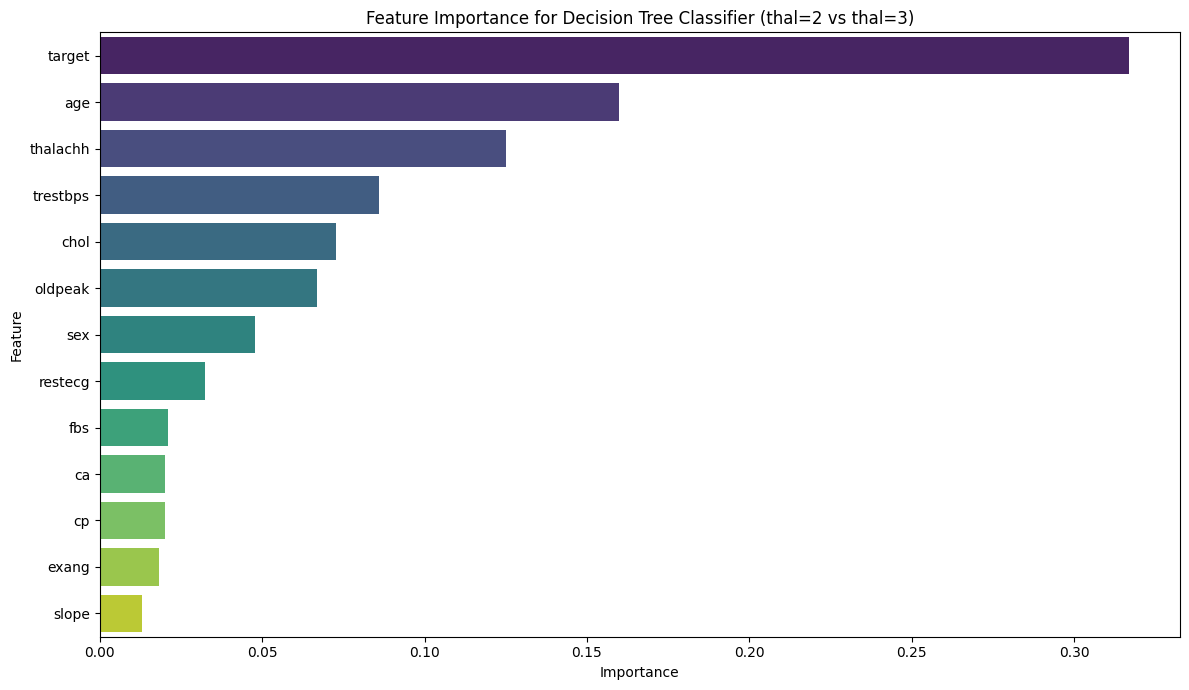

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Decision Tree Classifier
feature_importances = dt_classifier.feature_importances_

# Create a Series with feature names and their importances
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance for Decision Tree Classifier (thal=2 vs thal=3)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Decision Tree Visualization

Here is a visualization of the trained Decision Tree. This plot helps understand the decision rules learned by the model. Due to the tree's depth, it might be quite large; consider zooming in for details.

-   `samples`: The number of samples at that node.
-   `value`: The number of samples for each class at that node (e.g., `[count_thal_2, count_thal_3]`).
-   `class`: The majority class at that node.

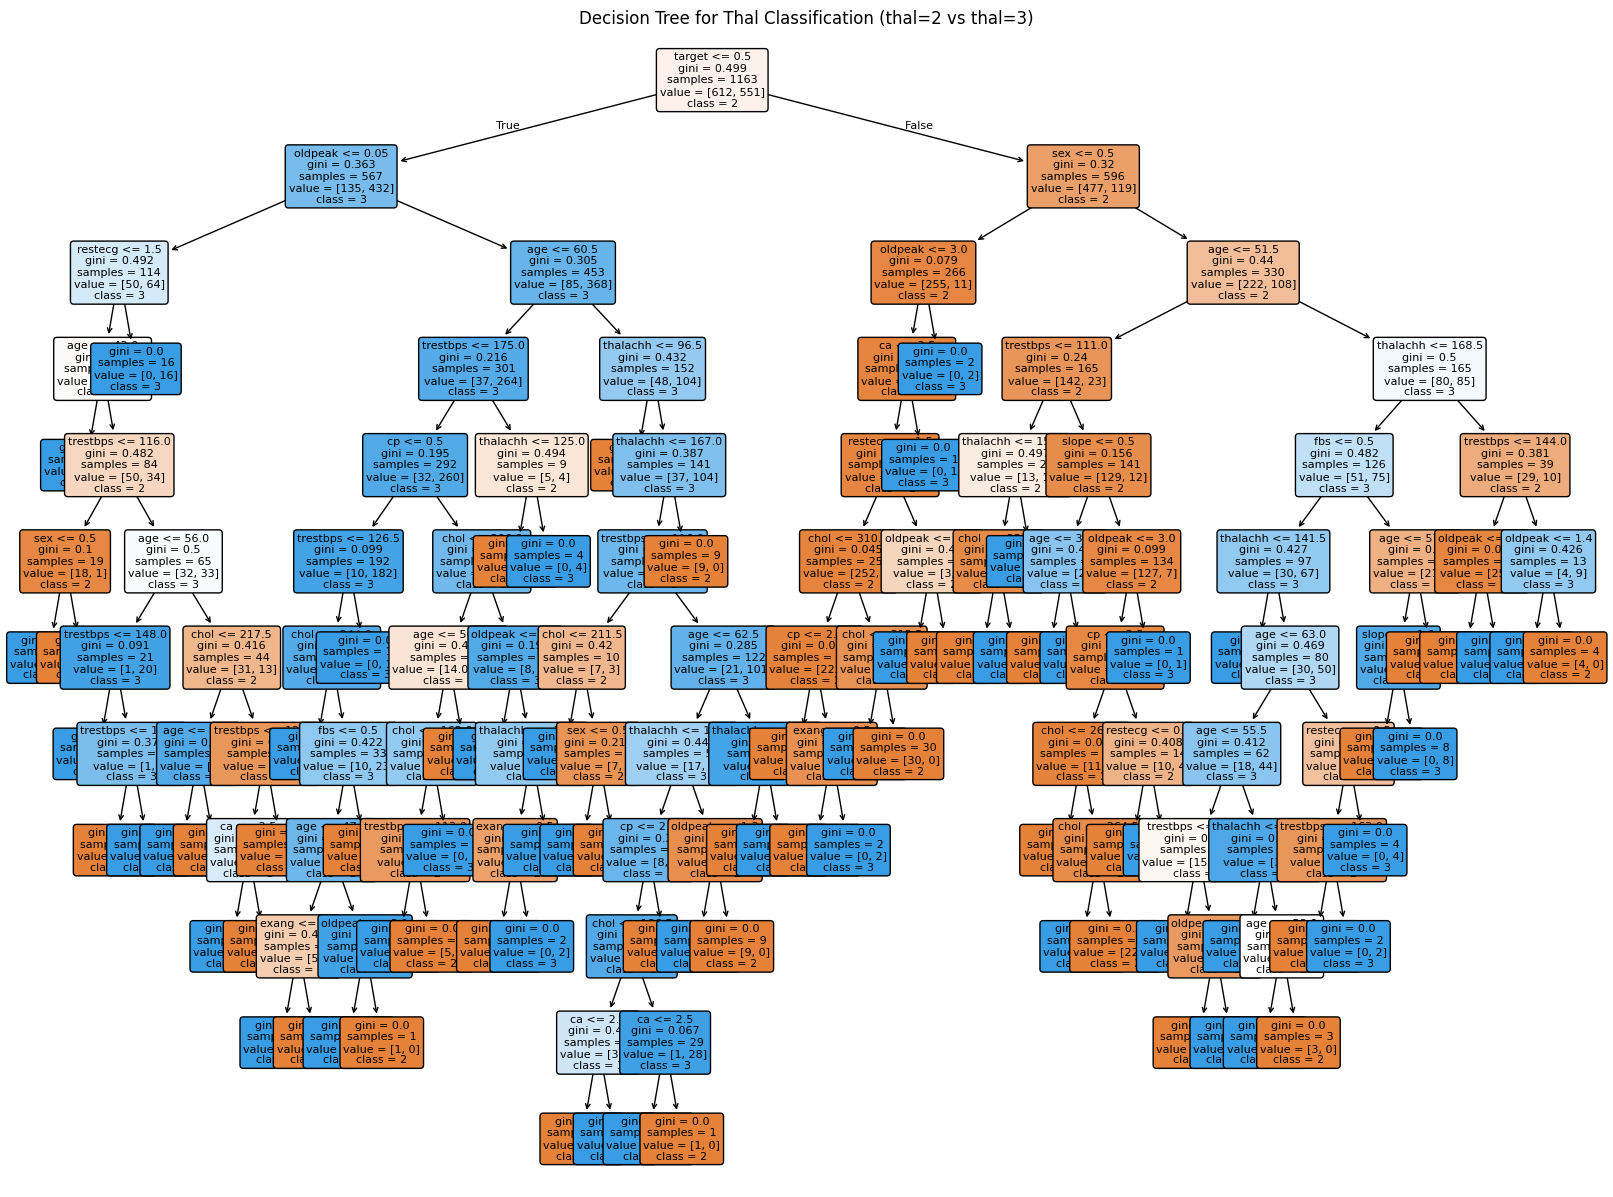

In [3]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15))
plot_tree(dt_classifier,
          feature_names=X.columns,
          class_names=[str(c) for c in dt_classifier.classes_],
          filled=True,
          rounded=True,
          proportion=False,
          fontsize=8)
plt.title('Decision Tree for Thal Classification (thal=2 vs thal=3)')
plt.show()